In [10]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import scipy.io

# Load data
mat_contents = scipy.io.loadmat('hw5_A.mat')
A_sparse = mat_contents['A']


## Ex.a

In [11]:
A = A_sparse
Q, R = np.linalg.qr(A, mode='reduced')  # "reduced" yields shapes (m, n) and (n, n)


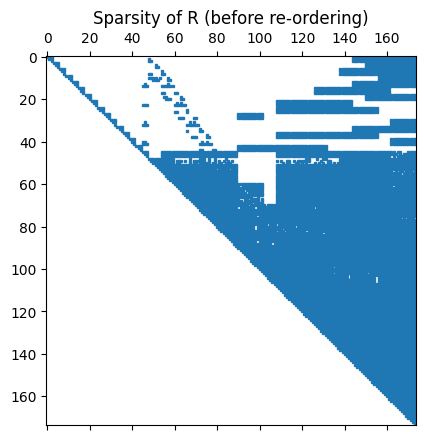

Number of nonzero entries in R before reordering: 9380


In [12]:
# Plotting the sparsity:
plt.figure()
plt.spy(R, markersize=2)
plt.title("Sparsity of R (before re-ordering)")
plt.show()

# Number of nonzeros:
nnz_before = np.count_nonzero(R)
print("Number of nonzero entries in R before reordering:", nnz_before)


## Ex.b

In [ ]:
# pip install Pyrebase4
# pip install scikit-sparse
from sksparse.cholmod import cholesky, colamd

# We will show a “pseudo‐QR” approach by factorizing (A^T A) with a
# reordering.  The Cholesky factor of A^T A is R^T, so you can
# glean R = (Cholesky factor)^T.

A_csc = A_sparse.tocsc()  # Convert to CSC, which CHOLMOD expects

# Compute a COLAMD ordering for A^T A
col_order = colamd(A_csc)  # Returns a permutation array of size n
# Reorder the columns of A
A_reordered = A_csc[:, col_order]
